# Oemof Cases Vergleich

Dieses Notebook lädt verschiedene oemof Dump-Dateien, restored die Energiesysteme und vergleicht die Ergebnisse.

**Funktionen:**
- Restore von gespeicherten Energiesystemen aus Dump-Dateien
- Extraktion der Ergebnisse in DataFrames
- Vergleich der Energiesummen verschiedener Cases
- Visualisierung der Unterschiede

## 1. Import der Bibliotheken

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from oemof.solph import EnergySystem, views
import logging
from oemof.tools import logger

# Konfiguration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Logging konfigurieren
logger.define_logging(
    logfile="oemof_compare.log",
    screen_level=logging.WARNING,
    file_level=logging.INFO,
)

print("✓ Bibliotheken erfolgreich geladen")

✓ Bibliotheken erfolgreich geladen


## 2. Hilfsfunktionen definieren

In [2]:
def get_dump_path():
    """Gibt den Pfad zum Dump-Ordner zurück"""
    # Das Notebook liegt in: results/oemof-V2H-WS25/timeseries/
    # Dumps liegen in:      results/oemof-V2H-WS25/dumps/
    notebook_dir = Path().resolve()
    
    # Gehe vom timeseries-Ordner zum oemof-V2H-WS25-Ordner und dann zu dumps
    dump_path = notebook_dir.parent / "dumps"
    
    return dump_path


def has_component(results: dict, component_name: str) -> bool:
    """Prüft ob eine Komponente in den Ergebnissen existiert"""
    for key in results.keys():
        if component_name in str(key[0]) or component_name in str(key[1]):
            return True
    return False


def extract_electricity_flows(results: dict) -> pd.DataFrame:
    """Extrahiert Elektrizitäts-Bus Flüsse mit deutschen Namen"""
    flows = {}
    
    for k, v in results.items():
        node_from = str(k[0])
        node_to = str(k[1])
        
        if node_from == "pv" and node_to == "electricity":
            flows["PV-Erzeugung [kW]"] = v["sequences"]["flow"]
        elif node_from == "electricity" and node_to in ["excess_electricity", "excess_bel"]:
            flows["Netzeinspeisung [kW]"] = v["sequences"]["flow"]
        elif node_from in ["grid_supply", "grid-supply"] and node_to == "electricity":
            flows["Netzbezug [kW]"] = v["sequences"]["flow"]
        elif node_from == "electricity" and node_to in ["household_demand", "demand"]:
            flows["Haushaltslast [kW]"] = v["sequences"]["flow"]
        elif node_from == "electricity" and node_to == "mobility":
            flows["Wallbox Ladung [kW]"] = v["sequences"]["flow"]
    
    return pd.DataFrame(flows)


def extract_battery_flows(results: dict, battery_label: str, prefix: str = "") -> pd.DataFrame:
    """Extrahiert Batterie-Flüsse und SOC"""
    node_data = views.node(results, battery_label)
    sequences = node_data["sequences"]
    
    flows = {}
    
    for col in sequences.columns:
        col_name = str(col[1]).lower() if len(col) > 1 else str(col).lower()
        
        # SOC
        if any(x in col_name for x in ['storage_content', 'soc', 'state_of_charge', 'content']):
            flows[f"{prefix} Ladezustand [kWh]"] = sequences[col]
        
        # Richtung prüfen
        node_from = str(col[0][0]) if isinstance(col[0], tuple) else ""
        node_to = str(col[0][1]) if isinstance(col[0], tuple) else ""
        
        if node_to == battery_label and 'flow' in col_name:
            flows[f"{prefix} Laden [kW]"] = sequences[col]
        elif node_from == battery_label and 'flow' in col_name:
            flows[f"{prefix} Entladen [kW]"] = sequences[col]
    
    return pd.DataFrame(flows)


print("✓ Hilfsfunktionen definiert")

✓ Hilfsfunktionen definiert


In [3]:
def restore_case(case_name: str) -> dict:
    """
    Restored einen Case und gibt ein Dictionary mit allen Daten zurück
    
    Parameters:
        case_name: Name des Cases (ohne Pfad)
    
    Returns:
        dict mit 'results' (oemof results), 'dataframe' (kombinierter DataFrame), 'case_name'
    """
    print(f"\nRestore: {case_name}...")
    
    # Restore Energiesystem - WICHTIG: Neues EnergySystem-Objekt für jeden Case!
    dump_path = get_dump_path()
    
    # Erstelle ein komplett neues EnergySystem-Objekt
    energysystem = EnergySystem()
    energysystem.restore(dpath=str(dump_path), filename=case_name)
    
    # Hole die Ergebnisse - WICHTIG: Kopiere die Ergebnisse sofort!
    results = energysystem.results["main"]
    
    # Debug: Zeige Anzahl der Result-Keys und ein paar Sample-Werte
    print(f"  - Anzahl Result-Keys: {len(results)}")
    
    # Hole einen Test-Wert um zu prüfen ob die Cases unterschiedlich sind
    test_key = None
    for k, v in results.items():
        if str(k[0]) == "pv" and str(k[1]) == "electricity":
            test_key = k
            test_sum = v["sequences"]["flow"].sum()
            print(f"  - PV-Erzeugung Summe: {test_sum:.2f}")
            break
    
    # Extrahiere Elektrizitäts-Flüsse
    elec_flows = extract_electricity_flows(results)
    
    # Extrahiere Batterie-Daten
    dfs_to_combine = [elec_flows]
    
    if has_component(results, "home_battery"):
        home_battery = extract_battery_flows(results, "home_battery", prefix="Heimspeicher")
        dfs_to_combine.append(home_battery)
    
    if has_component(results, "bev_battery"):
        bev_battery = extract_battery_flows(results, "bev_battery", prefix="BEV")
        dfs_to_combine.append(bev_battery)
    
    # Kombiniere alle Daten
    combined = pd.concat(dfs_to_combine, axis=1)
    
    print(f"  ✓ DataFrame erstellt: {len(combined.columns)} Spalten, {len(combined)} Zeitschritte")
    
    # Gebe ein Dictionary zurück mit allen Informationen
    return {
        'case_name': case_name,
        'results': results,
        'dataframe': combined.copy(),  # WICHTIG: Kopie erstellen!
        'energysystem': energysystem
    }


print("✓ Restore-Funktion definiert")

✓ Restore-Funktion definiert


## 3. Verfügbare Cases anzeigen

In [4]:
# Zeige verfügbare Dump-Dateien
dump_path = get_dump_path()

print("="*80)
print("VERFÜGBARE CASES IM DUMPS-ORDNER:")
print("="*80)
print(f"Pfad: {dump_path}\n")

if dump_path.exists():
    # Liste alle Dateien im dumps-Verzeichnis (nicht Ordner!)
    # Oemof speichert Dumps als Dateien ohne Endung
    cases = []
    for item in dump_path.iterdir():
        if item.is_file():  # GEÄNDERT: Suche nach Dateien, nicht Ordnern
            cases.append(item.name)
    
    cases.sort()
    
    if cases:
        for i, case in enumerate(cases, 1):
            print(f"{i:2d}. {case}")
        print(f"\n✓ {len(cases)} Cases gefunden")
    else:
        print("⚠ Keine Cases gefunden")
else:
    print(f"⚠ Dumps-Ordner nicht gefunden: {dump_path}")

print("="*80)

VERFÜGBARE CASES IM DUMPS-ORDNER:
Pfad: C:\git\github\HTW_V2H_WS25\results\oemof-V2H-WS25\dumps

 1. case11_pv_BEV_with_full_load_time_max_100h
 2. case11_pv_BEV_with_full_load_time_max_10h
 3. case11_pv_BEV_with_full_load_time_max_False

✓ 3 Cases gefunden


## 4. Cases laden und in Dictionary speichern

Wähle die Cases aus, die du vergleichen möchtest.

In [5]:
# KONFIGURATION: Wähle die Cases zum Vergleichen
# Verfügbare Cases (siehe Zelle oben - verwende die exakten Namen ohne Dateiendung)

cases_to_compare = cases

# Lade alle Cases - NEU: Speichere vollständige Case-Daten
print("="*80)
print("LADE CASES...")
print("="*80)

case_data_full = {}  # Vollständige Case-Daten mit results + dataframe
case_data = {}       # Nur DataFrames (für Kompatibilität)

for case_name in cases_to_compare:
    try:
        case_info = restore_case(case_name)
        case_data_full[case_name] = case_info
        case_data[case_name] = case_info['dataframe']
    except Exception as e:
        print(f"\n✗ Fehler bei {case_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print(f"✓ {len(case_data)} Cases erfolgreich geladen")
print("="*80)

LADE CASES...

Restore: case11_pv_BEV_with_full_load_time_max_100h...
  - Anzahl Result-Keys: 12
  - PV-Erzeugung Summe: 47534.05
  ✓ DataFrame erstellt: 7 Spalten, 35041 Zeitschritte

Restore: case11_pv_BEV_with_full_load_time_max_10h...
  - Anzahl Result-Keys: 12
  - PV-Erzeugung Summe: 47534.05
  ✓ DataFrame erstellt: 7 Spalten, 35041 Zeitschritte

Restore: case11_pv_BEV_with_full_load_time_max_False...
  - Anzahl Result-Keys: 12
  - PV-Erzeugung Summe: 47534.05
  ✓ DataFrame erstellt: 7 Spalten, 35041 Zeitschritte

✓ 3 Cases erfolgreich geladen


In [6]:
case_data_full

{'case11_pv_BEV_with_full_load_time_max_100h': {'case_name': 'case11_pv_BEV_with_full_load_time_max_100h',
  'results': {("<oemof.solph.components._generic_storage.GenericStorage: 'bev_battery'>",
    None): {'scalars': Series([], Name: 2022-01-01 00:00:00, dtype: float64),
    'sequences': variable_name        storage_content  storage_losses
    2022-01-01 00:00:00            73.15           -0.00
    2022-01-01 00:15:00            73.11           -0.00
    2022-01-01 00:30:00            73.07           -0.00
    2022-01-01 00:45:00            73.04           -0.00
    2022-01-01 01:00:00            73.00           -0.00
    ...                              ...             ...
    2022-12-31 23:00:00            17.73           -0.00
    2022-12-31 23:15:00            17.15           -0.00
    2022-12-31 23:30:00            16.57           -0.00
    2022-12-31 23:45:00            15.98           -0.00
    2023-01-01 00:00:00            15.40             NaN
    
    [35041 rows x 2 col

## 5. Berechne Energiesummen für jeden Case

In [7]:
def calculate_energy_sums(df: pd.DataFrame, case_name: str) -> pd.Series:
    """
    Berechnet Energiesummen für einen Case
    
    Parameters:
        df: DataFrame mit Zeitreihen
        case_name: Name des Cases
    
    Returns:
        Series mit Energiesummen
    """
    # Zeitschrittlänge berechnen (in Stunden)
    if len(df) > 1:
        time_step_hours = (df.index[1] - df.index[0]).total_seconds() / 3600
    else:
        time_step_hours = 0.25  # Default: 15 Minuten
    
    sums = {}
    
    # Berechne Summen für alle Leistungsspalten (ohne Ladezustand)
    for col in df.columns:
        if '[kW]' in col and 'Ladezustand' not in col:
            energy_kwh = (df[col] * time_step_hours).sum()
            sums[col.replace('[kW]', '[kWh]')] = energy_kwh
    
    # Maximale und minimale Ladezustände
    for col in df.columns:
        if 'Ladezustand' in col:
            sums[f"{col.replace('[kWh]', '')}Max [kWh]"] = df[col].max()
            sums[f"{col.replace('[kWh]', '')}Min [kWh]"] = df[col].min()
    
    return pd.Series(sums, name=case_name)


# Berechne Energiesummen für alle Cases
print("="*80)
print("BERECHNE ENERGIESUMMEN...")
print("="*80)

energy_comparison = pd.DataFrame()

for case_name, df in case_data.items():
    sums = calculate_energy_sums(df, case_name)
    energy_comparison[case_name] = sums

print(f"✓ Energiesummen für {len(energy_comparison.columns)} Cases berechnet")
print("="*80)

BERECHNE ENERGIESUMMEN...
✓ Energiesummen für 3 Cases berechnet


## 6. Vergleichstabelle anzeigen

In [8]:
# Zeige vollständige Vergleichstabelle
print("\n" + "="*80)
print("ENERGIESUMMEN-VERGLEICH")
print("="*80)
print("\n")
display(energy_comparison)


ENERGIESUMMEN-VERGLEICH




,case11_pv_BEV_with_full_load_time_max_100h,case11_pv_BEV_with_full_load_time_max_10h,case11_pv_BEV_with_full_load_time_max_False
Netzeinspeisung [kWh],6562.11,8800.13,6562.11
Haushaltslast [kWh],5010.10,5010.10,5010.10
Netzbezug [kWh],708.08,2621.58,708.08
PV-Erzeugung [kWh],11883.51,11883.51,11883.51
BEV Entladen [kWh],3052.99,926.88,3052.99
BEV Laden [kWh],2995.24,869.13,2995.24
BEV Ladezustand Max [kWh],73.15,73.15,73.15
BEV Ladezustand Min [kWh],15.40,15.40,15.40


In [9]:
# Berechne Differenzen zwischen Cases (falls 2 Cases)
if len(energy_comparison.columns) == 2:
    case1, case2 = energy_comparison.columns
    
    # Absolute Differenz
    energy_comparison['Differenz (absolut)'] = energy_comparison[case2] - energy_comparison[case1]
    
    # Relative Differenz in Prozent
    energy_comparison['Differenz (%)'] = (
        (energy_comparison[case2] - energy_comparison[case1]) / 
        energy_comparison[case1].abs() * 100
    ).replace([np.inf, -np.inf], np.nan)
    
    print("\n" + "="*80)
    print("VERGLEICH MIT DIFFERENZEN")
    print("="*80)
    display(energy_comparison)
elif len(energy_comparison.columns) > 2:
    print("\n⚠ Mehr als 2 Cases - Differenzen werden nicht automatisch berechnet")
    print("Tipp: Wähle genau 2 Cases für automatische Differenzberechnung")


⚠ Mehr als 2 Cases - Differenzen werden nicht automatisch berechnet
Tipp: Wähle genau 2 Cases für automatische Differenzberechnung


## 7. Visualisierung der Energiesummen

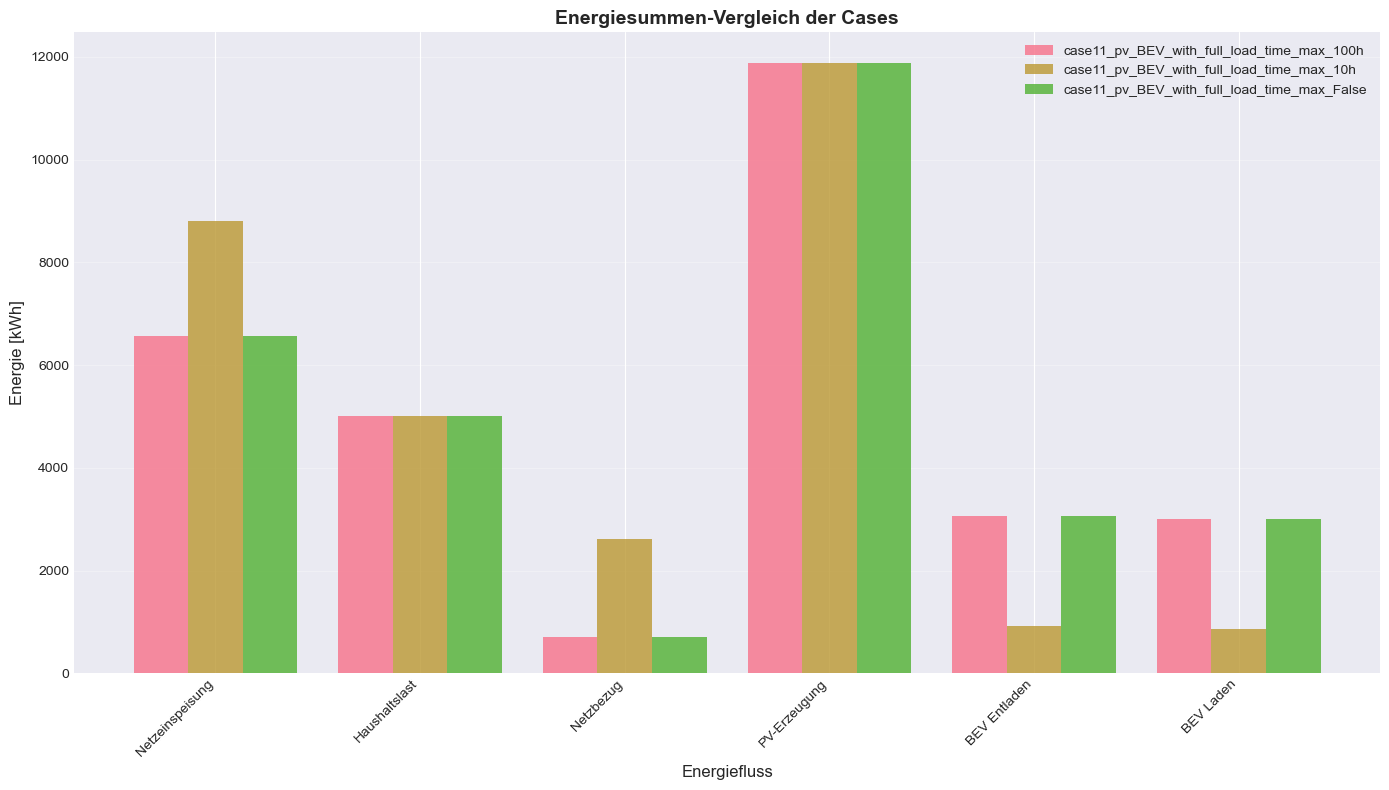

In [10]:
# Erstelle Balkendiagramm für Energiesummen (nur kWh-Spalten, keine Min/Max)
energy_cols = [col for col in energy_comparison.index if '[kWh]' in col and 'Max' not in col and 'Min' not in col]
comparison_cases = [col for col in energy_comparison.columns if 'Differenz' not in col]

if energy_cols:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(energy_cols))
    width = 0.8 / len(comparison_cases)
    
    for i, case in enumerate(comparison_cases):
        values = energy_comparison.loc[energy_cols, case]
        offset = (i - len(comparison_cases)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=case, alpha=0.8)
    
    ax.set_xlabel('Energiefluss', fontsize=12)
    ax.set_ylabel('Energie [kWh]', fontsize=12)
    ax.set_title('Energiesummen-Vergleich der Cases', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace(' [kWh]', '') for col in energy_cols], rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Keine Energiesummen zum Plotten gefunden")

## 8. Zeitreihen-Vergleich (optional)

Vergleiche ausgewählte Zeitreihen direkt.

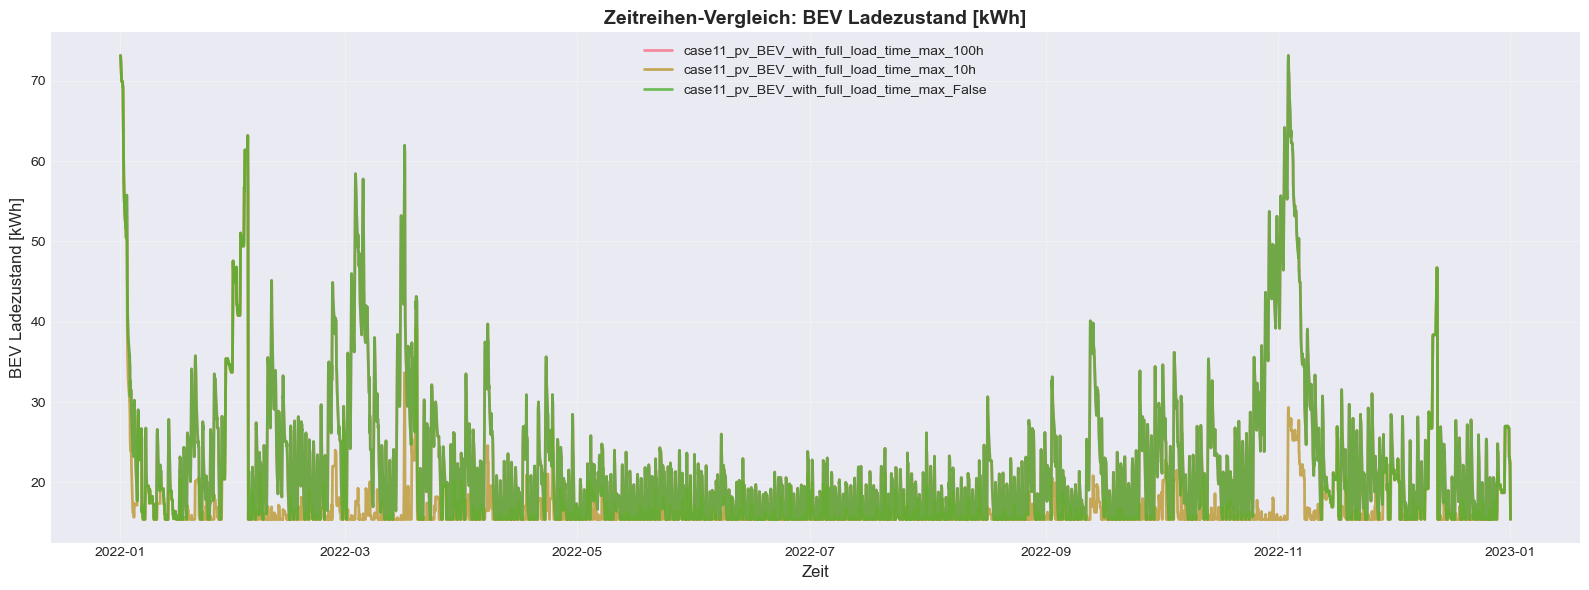

In [11]:
# Wähle eine Spalte zum Vergleich der Zeitreihen
column_to_compare = "BEV Ladezustand [kWh]"  # Ändern nach Bedarf

if column_to_compare:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    for case_name, df in case_data.items():
        if column_to_compare in df.columns:
            ax.plot(df.index, df[column_to_compare], label=case_name, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Zeit', fontsize=12)
    ax.set_ylabel(column_to_compare, fontsize=12)
    ax.set_title(f'Zeitreihen-Vergleich: {column_to_compare}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Bitte Spalte zum Vergleichen auswählen")

## 9. Ergebnisse exportieren

In [12]:
# Exportiere Vergleichstabelle als CSV
output_file = Path("case_comparison_energy_sums.csv")
energy_comparison.to_csv(output_file)
print(f"✓ Vergleichstabelle exportiert: {output_file}")

# Optional: Exportiere auch die vollständigen Zeitreihen
# for case_name, df in case_data.items():
#     output_file = Path(f"{case_name}_timeseries.csv")
#     df.to_csv(output_file)
#     print(f"✓ Zeitreihen exportiert: {output_file}")

✓ Vergleichstabelle exportiert: case_comparison_energy_sums.csv


## 10. Zusammenfassung und Kennzahlen

Berechne wichtige Kennzahlen für jeden Case.

In [13]:
# Berechne wichtige Kennzahlen
kennzahlen = pd.DataFrame()

for case_name in comparison_cases:
    kz = {}
    
    # PV-Erzeugung
    if 'PV-Erzeugung [kWh]' in energy_comparison.index:
        kz['PV-Erzeugung [kWh]'] = energy_comparison.loc['PV-Erzeugung [kWh]', case_name]
    
    # Haushaltslast
    if 'Haushaltslast [kWh]' in energy_comparison.index:
        kz['Haushaltslast [kWh]'] = energy_comparison.loc['Haushaltslast [kWh]', case_name]
    
    # Netzbezug
    if 'Netzbezug [kWh]' in energy_comparison.index:
        kz['Netzbezug [kWh]'] = energy_comparison.loc['Netzbezug [kWh]', case_name]
    
    # Netzeinspeisung
    if 'Netzeinspeisung [kWh]' in energy_comparison.index:
        kz['Netzeinspeisung [kWh]'] = energy_comparison.loc['Netzeinspeisung [kWh]', case_name]
    
    # Autarkiegrad (wenn möglich)
    if 'PV-Erzeugung [kWh]' in energy_comparison.index and 'Haushaltslast [kWh]' in energy_comparison.index and 'Netzbezug [kWh]' in energy_comparison.index:
        haushalt = energy_comparison.loc['Haushaltslast [kWh]', case_name]
        netzbezug = energy_comparison.loc['Netzbezug [kWh]', case_name]
        if haushalt > 0:
            autarkie = (1 - netzbezug / haushalt) * 100
            kz['Autarkiegrad [%]'] = autarkie
    
    # Eigenverbrauchsquote (wenn möglich)
    if 'PV-Erzeugung [kWh]' in energy_comparison.index and 'Netzeinspeisung [kWh]' in energy_comparison.index:
        pv_erzeugung = energy_comparison.loc['PV-Erzeugung [kWh]', case_name]
        einspeisung = energy_comparison.loc['Netzeinspeisung [kWh]', case_name]
        if pv_erzeugung > 0:
            eigenverbrauch = (1 - einspeisung / pv_erzeugung) * 100
            kz['Eigenverbrauchsquote [%]'] = eigenverbrauch
    
    kennzahlen[case_name] = pd.Series(kz)

print("\n" + "="*80)
print("WICHTIGE KENNZAHLEN")
print("="*80)
display(kennzahlen)
print("="*80)


WICHTIGE KENNZAHLEN


,case11_pv_BEV_with_full_load_time_max_100h,case11_pv_BEV_with_full_load_time_max_10h,case11_pv_BEV_with_full_load_time_max_False
PV-Erzeugung [kWh],11883.51,11883.51,11883.51
Haushaltslast [kWh],5010.10,5010.10,5010.10
Netzbezug [kWh],708.08,2621.58,708.08
Netzeinspeisung [kWh],6562.11,8800.13,6562.11
Autarkiegrad [%],85.87,47.67,85.87
Eigenverbrauchsquote [%],44.78,25.95,44.78


---

## ✓ Notebook bereit für Case-Vergleiche

**Nächste Schritte:**
1. Passe die `cases_to_compare` Liste in Zelle 4 an
2. Führe alle Zellen nacheinander aus
3. Analysiere die Ergebnisse und Visualisierungen
4. Exportiere die Vergleichstabelle bei Bedarf

**Tipps:**
- Füge weitere Cases zur Vergleichsliste hinzu
- Ändere `column_to_compare` für andere Zeitreihen-Vergleiche
- Erweitere die Kennzahlen-Berechnung nach Bedarf